In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
x = np.random.rand(100, 1) - 0.5
y = 3 * x[:, 0] ** 2 + 0.05 * np.random.randn(100)

In [4]:
import pandas as pd
df = pd.DataFrame()

In [5]:
df['x'] = x.reshape(100)
df['y'] = y

In [6]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


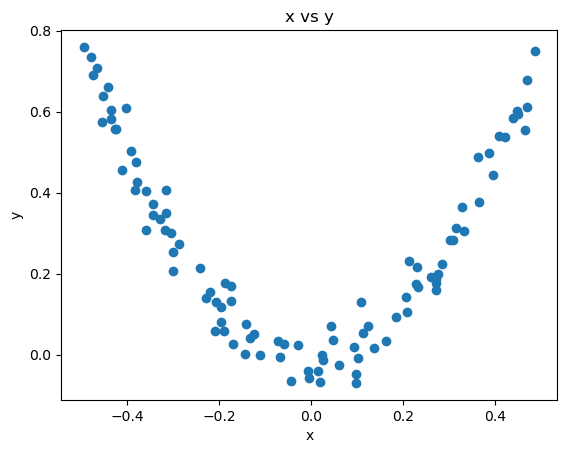

In [7]:
plt.scatter(df["x"], df["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.show()

In [8]:
df['pred1'] = df['y'].mean()
df.head()

,x,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [9]:
df['res1'] = df['y'] - df['pred1']
df.head()

,x,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


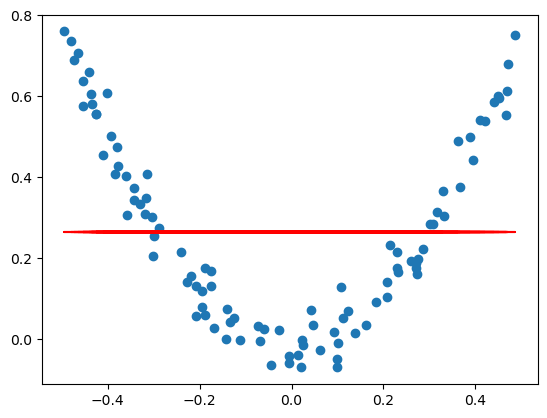

In [10]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['pred1'], color='red')

In [11]:
from sklearn.tree import DecisionTreeRegressor
tree1 = DecisionTreeRegressor(max_leaf_nodes= 8, random_state=42)

In [12]:
tree1.fit(df[['x']], df['res1'])

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.4090909090909091, 0.9166666666666666, 'x[0] <= -0.36\nsquared_error = 0.056\nsamples = 100\nvalue = 0.0'),
 Text(0.18181818181818182, 0.75, 'x[0] <= -0.43\nsquared_error = 0.012\nsamples = 18\nvalue = 0.309'),
 Text(0.29545454545454547, 0.8333333333333333, 'True  '),
 Text(0.09090909090909091, 0.5833333333333334, 'squared_error = 0.004\nsamples = 9\nvalue = 0.395'),
 Text(0.2727272727272727, 0.5833333333333334, 'squared_error = 0.005\nsamples = 9\nvalue = 0.222'),
 Text(0.6363636363636364, 0.75, 'x[0] <= 0.322\nsquared_error = 0.04\nsamples = 82\nvalue = -0.068'),
 Text(0.5227272727272727, 0.8333333333333333, '  False'),
 Text(0.45454545454545453, 0.5833333333333334, 'x[0] <= -0.235\nsquared_error = 0.016\nsamples = 67\nvalue = -0.142'),
 Text(0.36363636363636365, 0.4166666666666667, 'squared_error = 0.003\nsamples = 12\nvalue = 0.041'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[0] <= 0.211\nsquared_error = 0.009\nsamples = 55\nvalue = -0.182'),
 Text(0.45454545454545453

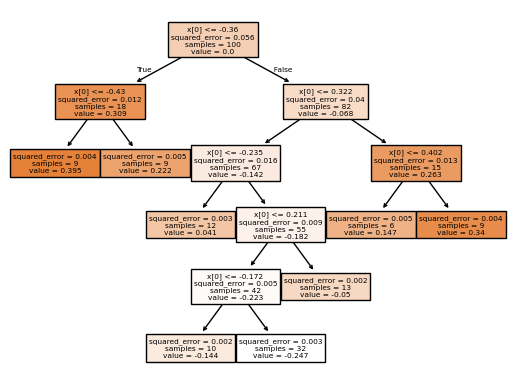

In [13]:
from sklearn.tree import plot_tree
plot_tree(tree1, filled=True)

In [14]:
x_test = np.linspace(-0.5, 0.5, 500).reshape(500, 1)

In [15]:
y_pred = 0.2654583 + tree1.predict(x_test)

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'pred1 vs data')

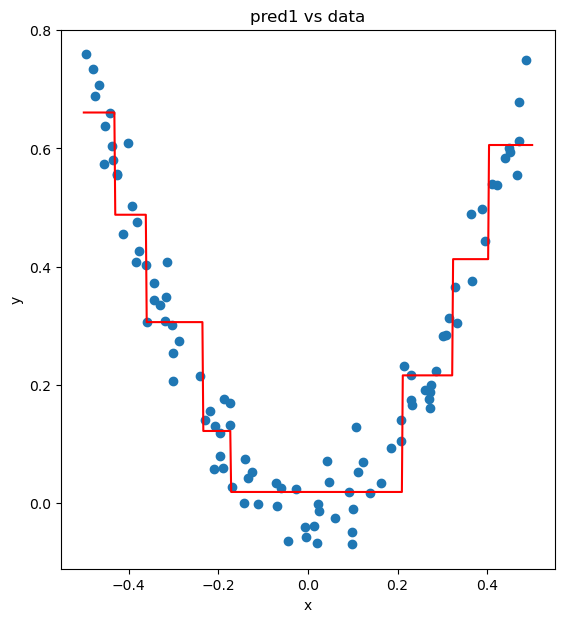

In [16]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(x_test, y_pred, color='red', label='pred1')
plt.scatter(df['x'], df['y'], label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('pred1 vs data')

In [17]:
df['pred2'] = 0.26545 + tree1.predict(df['x'].values.reshape(100, 1))

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [18]:
df

,x,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018311
1,0.450714,0.594480,0.265458,0.329021,0.605876
2,0.231994,0.166052,0.265458,-0.099407,0.215776
3,0.098658,-0.070178,0.265458,-0.335636,0.018311
4,-0.343981,0.343986,0.265458,0.078528,0.305956
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018311
96,0.022733,-0.002305,0.265458,-0.267763,0.018311
97,-0.072459,0.032809,0.265458,-0.232650,0.018311
98,-0.474581,0.689516,0.265458,0.424057,0.660904


In [19]:
df['res2'] = df['y'] - df['pred2']
df.head()

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018311,0.033262
1,0.450714,0.594480,0.265458,0.329021,0.605876,-0.011396
2,0.231994,0.166052,0.265458,-0.099407,0.215776,-0.049724
3,0.098658,-0.070178,0.265458,-0.335636,0.018311,-0.088489
4,-0.343981,0.343986,0.265458,0.078528,0.305956,0.038030


In [21]:
tree2 = DecisionTreeRegressor(max_leaf_nodes= 8, random_state=42)
tree2.fit(df[['x']], df['res2'])

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [22]:
y_pred2 = 0.26545 + sum(regressor.predict(x_test) for regressor in [tree1, tree2])

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'pred2 vs data')

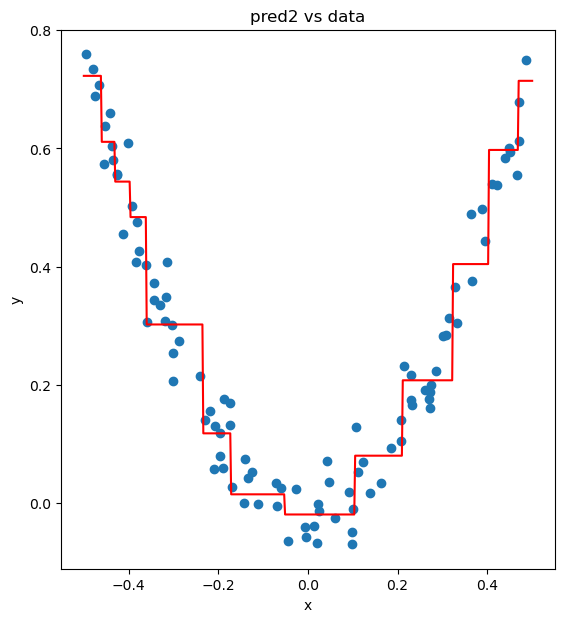

In [23]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(x_test, y_pred2, color='red', label='pred2')
plt.scatter(df['x'], df['y'], label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('pred2 vs data')


In [26]:
def gradint_boost(x, y, n_estimators, lr):
    base_pred = y.mean()                # scalar
    residual = y - base_pred            # shape (100,)
    regs = []
    x_plot = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)

    for i in range(n_estimators):
        tree = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
        tree.fit(x, residual)
        regs.append(tree)

        # ensemble predictions
        y_train_pred = base_pred + lr * sum(reg.predict(x) for reg in regs)   # (100,)
        residual = y - y_train_pred

        y_plot_pred = base_pred + lr * sum(reg.predict(x_plot) for reg in regs)  # (500,)

        plt.figure(figsize=(8, 4))
        plt.plot(x_plot, y_plot_pred, color='red', label=f'pred {i+1}')
        plt.scatter(x, y, label='data', alpha=0.6)
        plt.title(f'Gradient boost iteration {i+1}')
        plt.legend()
        plt.show()

    return regs


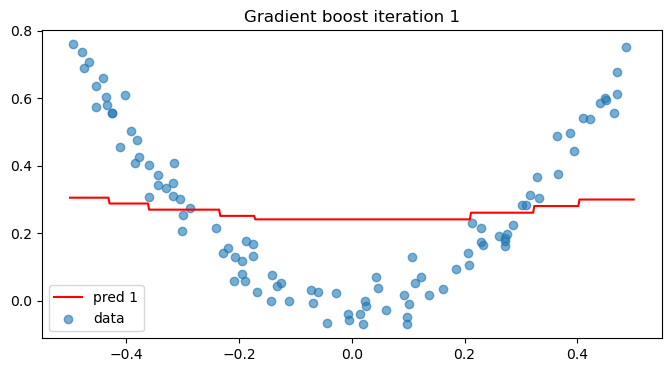

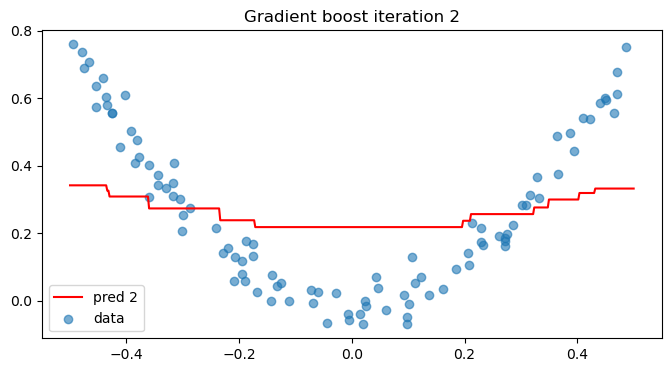

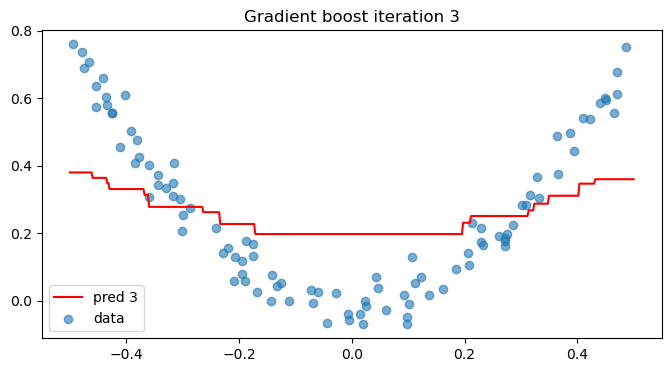

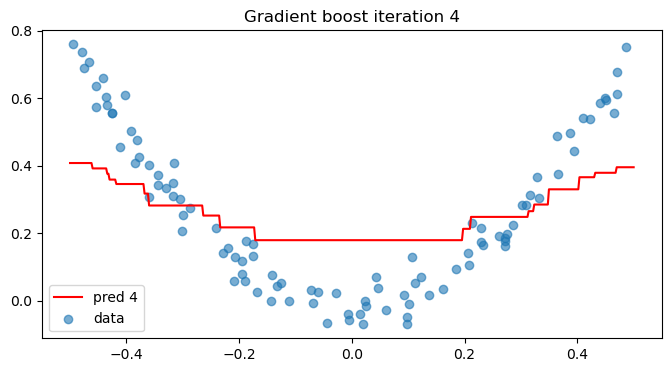

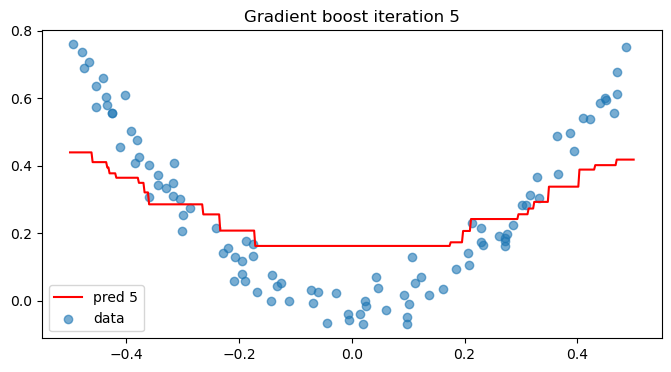

[DecisionTreeRegressor(max_leaf_nodes=8, random_state=42),
 DecisionTreeRegressor(max_leaf_nodes=8, random_state=42),
 DecisionTreeRegressor(max_leaf_nodes=8, random_state=42),
 DecisionTreeRegressor(max_leaf_nodes=8, random_state=42),
 DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)]

In [27]:
np.random.seed(42)
x = np.random.rand(100, 1) - 0.5
y = 3 * x[:, 0] ** 2 + 0.05 * np.random.randn(100)
np.random.seed(42)
x = np.random.rand(100, 1) - 0.5
y = 3 * x[:, 0] ** 2 + 0.05 * np.random.randn(100)


gradint_boost(x, y, 5, 0.1)